# Lab 3: 예방정비 스케줄 최적화 & ROI 계산
## 목표: RUL 예측 결과를 현장 정비 계획으로 연결하고 경제적 효과를 계산한다

### 실습 흐름
```
예측 RUL 로드 → 정비 우선순위 분류 → 전략 비교(TBM/PM/PdM) → 비용 계산 → ROI → Gantt 스케줄
```

## 학습 목표

이 실습을 마치면 다음을 할 수 있습니다:

| # | 학습 성과 | 현장 의미 |
|---|----------|---------|
| 1 | 3가지 정비 전략(TBM/PM/PdM)을 비교 설명할 수 있다 | 전략 선택 근거 제시 |
| 2 | 정비 비용 함수를 구현하고 계산할 수 있다 | ROI 분석 자동화 |
| 3 | 시나리오별 ROI를 계산하고 시각화할 수 있다 | 경영진 보고용 자료 작성 |
| 4 | Gantt 차트로 정비 스케줄을 시각화할 수 있다 | 현장 공유 가능한 일정표 |

In [1]:
# ============================================================
# 필수 라이브러리 임포트
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as cm
from datetime import datetime, timedelta

# 재현성 시드 고정
np.random.seed(42)

# matplotlib 설정
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

# Jupyter 환경 display() 처리
try:
    from IPython.display import display
    HAS_DISPLAY = True
except ImportError:
    HAS_DISPLAY = False
    def display(df): print(df.to_string())

print('✅ 라이브러리 로드 완료')

✅ 라이브러리 로드 완료


> ### 🎓 강사 가이드 — 1단계: 정비 전략 개요 & RUL 결과 통합
>
> | 항목 | 내용 |
> |------|------|
> | ⏱️ 소요 시간 | 약 10분 |
> | 🎯 핵심 목표 | Track A 전체 파이프라인 복습 — 이상탐지 + RUL 예측 → 정비 결정 |
> | 🔑 핵심 개념 | 3가지 전략 비교: BM(사후) < PM(예방) < PdM(예지보전) 비용 효율 |
>
> **💡 강조 포인트**
> - BM(사후정비): 고장 후 수리 → 계획 외 가동 중단, 높은 손실
> - PM(예방정비): 주기적 교체 → 과잉 정비 가능성
> - PdM(예지보전): 상태 기반 → 최적 시점 정비
>
> **🚨 주의사항**: 이전 Lab에서 생성한 `rul_signal.json` 파일이 없으면 시뮬레이션 데이터로 대체됨
>
> **❓ 생각해보기**: "예지보전이 항상 최선일까요? 도입이 어려운 상황은 어떤 경우일까요?"

## 1단계: 정비 전략 개요

### 3가지 정비 전략 비교

| 전략 | 약어 | 방식 | 장점 | 단점 |
|------|------|------|------|------|
| **사후보전** | TBM (Time-Based/Break-down) | 고장 후 수리 | 비용 없음 | 예기치 못한 다운타임 |
| **예방보전** | PM (Preventive Maintenance) | 주기적 교체 | 고장 예방 | 과잉 정비 비용 |
| **예지보전** | PdM (Predictive Maintenance) | 예측 기반 교체 | 최적 시점 | AI 시스템 투자 필요 |

**예지보전(PdM)의 핵심**: Lab 2의 LSTM RUL 예측 → 정비 필요 시점을 사전에 알아 최적 시점에 교체

In [2]:
# ============================================================
# 예측 RUL 결과 로드 (Lab 2 출력 또는 시뮬레이션)
# ============================================================
# 실제 환경에서는 Lab 2의 LSTM 모델 예측 결과를 사용:
#   import pickle
#   y_pred_real = pickle.load(open('outputs/rul_predictions.pkl', 'rb'))
# ============================================================

N_UNITS = 12
CURRENT_CYCLE = 150  # 현재 사이클 (기준 시점)
CYCLES_PER_DAY = 2   # 1일 평균 2사이클 운전 가정

# 12개 설비의 예측 RUL (Lab 2 LSTM 결과 시뮬레이션)
# 긴급/주의/양호 각 구간이 골고루 포함되도록 설정
predicted_ruls = np.array([8, 15, 22, 35, 45, 62, 75, 95, 115, 140, 168, 195])

# 정비 스케줄 DataFrame 생성
schedule_data = {
    'unit_id': [f'EQ-{i:03d}' for i in range(1, N_UNITS + 1)],
    'predicted_rul': predicted_ruls,
    'current_cycle': [CURRENT_CYCLE] * N_UNITS,
    'last_maintenance_cycle': np.random.randint(60, 130, N_UNITS),
    'line': np.random.choice(['Line-A', 'Line-B', 'Line-C'], N_UNITS),
    'cycles_since_maintenance': CURRENT_CYCLE - np.random.randint(60, 130, N_UNITS)
}

df = pd.DataFrame(schedule_data)

# 예상 고장 사이클 및 일수 계산
df['predicted_failure_cycle'] = df['current_cycle'] + df['predicted_rul']
df['days_until_failure'] = df['predicted_rul'] / CYCLES_PER_DAY

# 우선순위 분류 함수
def classify_priority(rul):
    """RUL 기반 정비 우선순위 분류"""
    if rul <= 20:
        return '긴급 (RED)'
    elif rul <= 50:
        return '주의 (ORANGE)'
    elif rul <= 100:
        return '경계 (YELLOW)'
    else:
        return '양호 (GREEN)'

df['priority'] = df['predicted_rul'].apply(classify_priority)
df_sorted = df.sort_values('predicted_rul').reset_index(drop=True)

print(f'총 유닛 수: {N_UNITS}대 | 현재 사이클: {CURRENT_CYCLE}')
print(f'1사이클 = 0.5일 (CYCLES_PER_DAY = {CYCLES_PER_DAY})')
print()
print('우선순위별 현황:')
for p, count in df['priority'].value_counts().items():
    print(f'  {p}: {count}대')

print('\n정비 스케줄 (잔여 수명 오름차순):')
display(df_sorted[['unit_id', 'line', 'predicted_rul', 'days_until_failure', 'priority']]
        .rename(columns={'predicted_rul': 'RUL(cycles)', 'days_until_failure': 'D-day'}))

총 유닛 수: 12대 | 현재 사이클: 150
1사이클 = 0.5일 (CYCLES_PER_DAY = 2)

우선순위별 현황:
  양호 (GREEN): 4대
  주의 (ORANGE): 3대
  경계 (YELLOW): 3대
  긴급 (RED): 2대

정비 스케줄 (잔여 수명 오름차순):


,unit_id,line,RUL(cycles),D-day,priority
0,EQ-001,Line-A,8,4.0,긴급 (RED)
1,EQ-002,Line-A,15,7.5,긴급 (RED)
2,EQ-003,Line-B,22,11.0,주의 (ORANGE)
3,EQ-004,Line-B,35,17.5,주의 (ORANGE)
4,EQ-005,Line-A,45,22.5,주의 (ORANGE)
5,EQ-006,Line-A,62,31.0,경계 (YELLOW)
6,EQ-007,Line-A,75,37.5,경계 (YELLOW)
7,EQ-008,Line-C,95,47.5,경계 (YELLOW)
8,EQ-009,Line-C,115,57.5,양호 (GREEN)
9,EQ-010,Line-C,140,70.0,양호 (GREEN)


> ### 🎓 강사 가이드 — 2단계: 정비 우선순위 시각화
>
> | 항목 | 내용 |
> |------|------|
> | ⏱️ 소요 시간 | 약 10분 |
> | 🎯 핵심 목표 | 예측 RUL 기반으로 긴급 정비 vs 계획 정비 우선순위 결정 |
> | 🔑 핵심 개념 | RUL이 낮을수록 긴급도 높음 → 색상 코딩으로 직관적 우선순위 표현 |
>
> **💡 강조 포인트**
> - 색상 코딩: 빨강(즉시) → 주황(1주) → 초록(정상)
> - 현장 엔지니어에게 직관적으로 전달 가능한 대시보드 형태
>
> **🚨 주의사항**: RUL 예측 불확실성을 고려하여 safety margin을 두는 것이 중요
>
> **❓ 생각해보기**: "같은 RUL이지만 중요도가 다른 설비라면 우선순위를 어떻게 정할까요?"

## 2단계: 정비 우선순위 시각화

/var/folders/mh/1jd1y3rx7l7dkgc510k_241w0000gn/T/ipykernel_25105/3918565222.py:55: UserWarning: Glyph 44596 (\N{HANGUL SYLLABLE GIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/mh/1jd1y3rx7l7dkgc510k_241w0000gn/T/ipykernel_25105/3918565222.py:55: UserWarning: Glyph 44553 (\N{HANGUL SYLLABLE GEUB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/mh/1jd1y3rx7l7dkgc510k_241w0000gn/T/ipykernel_25105/3918565222.py:55: UserWarning: Glyph 51593 (\N{HANGUL SYLLABLE JEUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/mh/1jd1y3rx7l7dkgc510k_241w0000gn/T/ipykernel_25105/3918565222.py:55: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/mh/1jd1y3rx7l7dkgc510k_241w0000gn/T/ipykernel_25105/3918565222.py:55: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/mh/1jd1y3rx7l7dkgc510k_241w0000gn/T/ipy

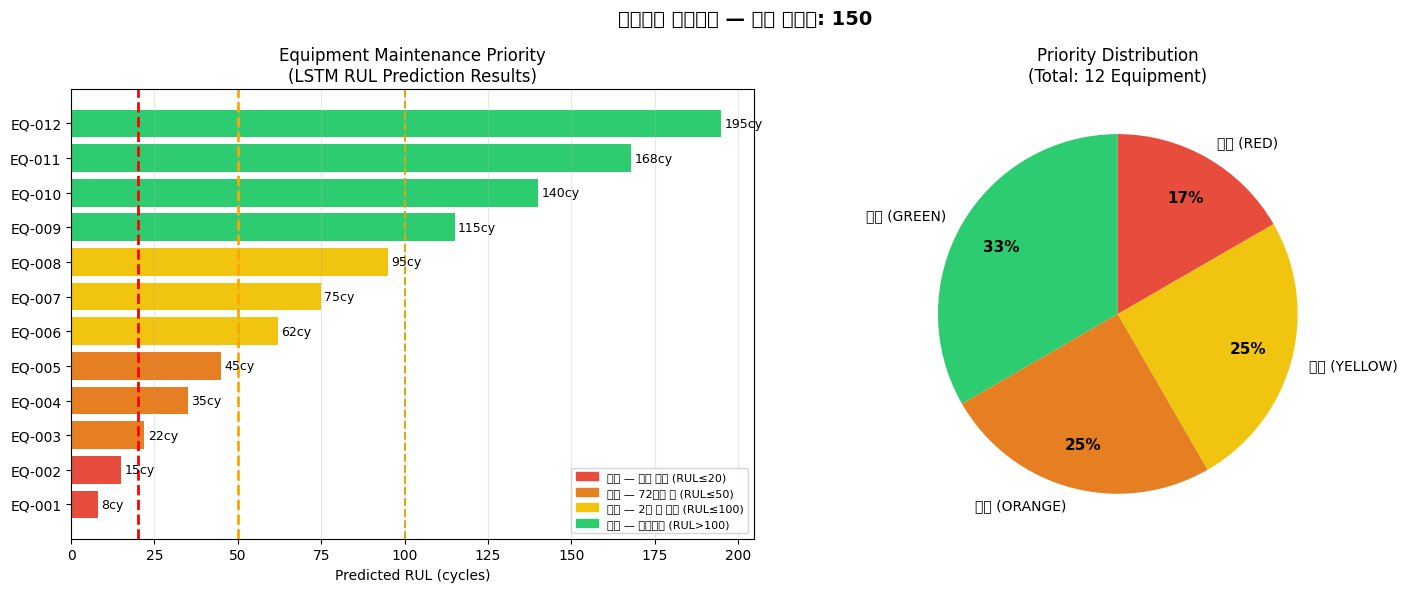

In [3]:
# ============================================================
# 우선순위별 정비 일정 시각화
# ============================================================
color_map = {
    '긴급 (RED)':   '#e74c3c',
    '주의 (ORANGE)': '#e67e22',
    '경계 (YELLOW)': '#f1c40f',
    '양호 (GREEN)':  '#2ecc71'
}
bar_colors = [color_map[p] for p in df_sorted['priority']]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# (1) 수평 막대 차트 — 설비별 잔여 수명
bars = axes[0].barh(df_sorted['unit_id'], df_sorted['predicted_rul'], color=bar_colors)
axes[0].axvline(20, color='red', linestyle='--', linewidth=2, label='긴급 기준 (20 cycles)')
axes[0].axvline(50, color='orange', linestyle='--', linewidth=2, label='주의 기준 (50 cycles)')
axes[0].axvline(100, color='#d4ac0d', linestyle='--', linewidth=1.5, label='경계 기준 (100 cycles)')

# 수치 표시
for bar, rul in zip(bars, df_sorted['predicted_rul']):
    axes[0].text(rul + 1, bar.get_y() + bar.get_height()/2,
                 f'{rul}cy', va='center', fontsize=9)

# 범례 패치
legend_patches = [
    mpatches.Patch(color='#e74c3c', label='긴급 — 즉시 정비 (RUL≤20)'),
    mpatches.Patch(color='#e67e22', label='주의 — 72시간 내 (RUL≤50)'),
    mpatches.Patch(color='#f1c40f', label='경계 — 2주 내 계획 (RUL≤100)'),
    mpatches.Patch(color='#2ecc71', label='양호 — 모니터링 (RUL>100)'),
]
axes[0].legend(handles=legend_patches, loc='lower right', fontsize=8)
axes[0].set_xlabel('Predicted RUL (cycles)')
axes[0].set_title('Equipment Maintenance Priority\n(LSTM RUL Prediction Results)')
axes[0].grid(alpha=0.3, axis='x')

# (2) 파이 차트 — 우선순위 분포
priority_counts = df['priority'].value_counts()
pie_colors = [color_map[p] for p in priority_counts.index]
wedges, texts, autotexts = axes[1].pie(
    priority_counts.values,
    labels=priority_counts.index,
    colors=pie_colors,
    autopct='%1.0f%%',
    startangle=90,
    pctdistance=0.75
)
for text in autotexts:
    text.set_fontsize(11)
    text.set_fontweight('bold')
axes[1].set_title(f'Priority Distribution\n(Total: {N_UNITS} Equipment)')

plt.suptitle(f'예방정비 대시보드 — 기준 사이클: {CURRENT_CYCLE}',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

> ### 🎓 강사 가이드 — 3단계: 정비 비용 모델링
>
> | 항목 | 내용 |
> |------|------|
> | ⏱️ 소요 시간 | 약 15분 |
> | 🎯 핵심 목표 | 예방정비 vs 사후정비의 ROI 비교를 통한 의사결정 근거 수립 |
> | 🔑 핵심 개념 | 고장 비용 = 수리비 + 생산 손실 + 품질 불량 비용 |
>
> **💡 강조 포인트**
> - 예방정비 비용 < 고장 비용 (일반적으로 5~10배 차이)
> - 부품 교체 + 인건비 + 생산 중단 시간을 모두 포함해야 함
>
> **🚨 주의사항**: 비용 모델은 가정(assumption)에 따라 결과가 크게 달라짐 — 감도 분석 중요
>
> **❓ 생각해보기**: "생산 손실 비용을 추정할 때 어떤 데이터가 필요할까요?"

## 3단계: 정비 전략별 비용 계산

### 비용 모델

| 전략 | 비용 구성 요소 |
|------|---------------|
| **TBM** (사후) | 긴급 수리비 + 생산 중단 손실 |
| **PM** (예방) | 정기 교체비 + 과잉 정비 손실 |
| **PdM** (예지) | 시스템 구축비 + 최적 타이밍 정비비 |

In [4]:
# ============================================================
# 정비 비용 계산 함수
# ============================================================

def calculate_maintenance_cost(
    strategy: str,
    failure_rate: float,       # 연간 고장 발생 확률 (0.0~1.0)
    repair_cost: float,        # 사후 긴급 수리 비용 (만원/회)
    pm_cost: float,            # 예방정비 비용 (만원/회)
    pdm_cost: float,           # 예지정비 비용 (만원/회, AI 시스템 포함)
    production_loss: float,    # 고장 시 생산 중단 손실 (만원/시간)
    downtime_hours: float,     # 고장 시 평균 복구 시간 (시간)
    n_equipment: int,          # 관리 설비 수
    pdm_efficiency: float      # PdM 고장 예방 효율 (0.0~1.0)
) -> dict:
    """
    정비 전략별 연간 총 비용 계산
    
    Returns:
        dict: 전략별 비용 상세 내역
    """
    # 예상 고장 횟수 (연간)
    expected_failures = failure_rate * n_equipment
    
    # 고장 당 총 손실 비용
    total_loss_per_failure = repair_cost + production_loss * downtime_hours
    
    if strategy == 'TBM':  # 사후 보전 — 고장 후 수리
        annual_cost = expected_failures * total_loss_per_failure
        detail = {
            '전략': 'TBM (사후보전)',
            '연간_고장_횟수': round(expected_failures, 1),
            '고장당_비용(만원)': round(total_loss_per_failure),
            '예방_비용(만원)': 0,
            '고장_손실(만원)': round(expected_failures * total_loss_per_failure),
            '연간_총비용(만원)': round(annual_cost)
        }
    
    elif strategy == 'PM':  # 예방 보전 — 주기적 교체 (과잉 정비 포함)
        # PM은 필요 여부와 무관하게 정기 교체 → 과잉 정비율 30% 가정
        pm_frequency = n_equipment * 2  # 연 2회 점검
        pm_total = pm_cost * pm_frequency
        # PM으로도 일부 고장은 막지 못함 (예방율 70% 가정)
        residual_failures = expected_failures * 0.30
        residual_loss = residual_failures * total_loss_per_failure
        annual_cost = pm_total + residual_loss
        detail = {
            '전략': 'PM (예방보전)',
            '연간_정비_횟수': pm_frequency,
            '정비비용_합계(만원)': round(pm_total),
            '잔여고장_손실(만원)': round(residual_loss),
            '예방_비용(만원)': round(pm_total),
            '고장_손실(만원)': round(residual_loss),
            '연간_총비용(만원)': round(annual_cost)
        }
    
    elif strategy == 'PdM':  # 예지 보전 — RUL 예측 기반 최적 시점 정비
        # PdM: 필요한 설비만 정비 → 정비 횟수 최소화
        pdm_frequency = expected_failures * 1.2  # 예측 기반 정비 (20% 안전 마진)
        pdm_total = pdm_cost * pdm_frequency
        # PdM으로 고장의 pdm_efficiency% 예방
        prevented_failures = expected_failures * pdm_efficiency
        remaining_failures = expected_failures * (1 - pdm_efficiency)
        remaining_loss = remaining_failures * total_loss_per_failure
        annual_cost = pdm_total + remaining_loss
        detail = {
            '전략': 'PdM (예지보전)',
            '예측_정비_횟수': round(pdm_frequency, 1),
            '예방된_고장수': round(prevented_failures, 1),
            '잔여고장_손실(만원)': round(remaining_loss),
            '예방_비용(만원)': round(pdm_total),
            '고장_손실(만원)': round(remaining_loss),
            '연간_총비용(만원)': round(annual_cost)
        }
    
    else:
        raise ValueError(f'Unknown strategy: {strategy}')
    
    return detail


# 기본 파라미터 설정
BASE_PARAMS = {
    'failure_rate': 0.30,       # 연간 고장 확률 30%
    'repair_cost': 300,         # 긴급 수리비 300만원
    'pm_cost': 80,              # 예방정비비 80만원
    'pdm_cost': 100,            # 예지정비비 100만원 (AI 비용 포함)
    'production_loss': 50,      # 생산 손실 50만원/시간
    'downtime_hours': 8,        # 평균 복구 8시간
    'n_equipment': N_UNITS,     # 12대
    'pdm_efficiency': 0.85      # PdM 고장 예방율 85%
}

# 3가지 전략 계산
tbm_result = calculate_maintenance_cost('TBM', **BASE_PARAMS)
pm_result  = calculate_maintenance_cost('PM',  **BASE_PARAMS)
pdm_result = calculate_maintenance_cost('PdM', **BASE_PARAMS)

print('=== 정비 전략별 연간 비용 비교 ===')
for result in [tbm_result, pm_result, pdm_result]:
    print(f"\n  [{result['전략']}]")
    for k, v in result.items():
        if k != '전략':
            print(f'    {k}: {v}')

=== 정비 전략별 연간 비용 비교 ===

  [TBM (사후보전)]
    연간_고장_횟수: 3.6
    고장당_비용(만원): 700
    예방_비용(만원): 0
    고장_손실(만원): 2520
    연간_총비용(만원): 2520

  [PM (예방보전)]
    연간_정비_횟수: 24
    정비비용_합계(만원): 1920
    잔여고장_손실(만원): 756
    예방_비용(만원): 1920
    고장_손실(만원): 756
    연간_총비용(만원): 2676

  [PdM (예지보전)]
    예측_정비_횟수: 4.3
    예방된_고장수: 3.1
    잔여고장_손실(만원): 378
    예방_비용(만원): 432
    고장_손실(만원): 378
    연간_총비용(만원): 810


> ### 🎓 강사 가이드 — 4단계: 전략 비용 비교 시각화
>
> | 항목 | 내용 |
> |------|------|
> | ⏱️ 소요 시간 | 약 10분 |
> | 🎯 핵심 목표 | 3가지 정비 전략의 연간 총비용을 시각적으로 비교 |
> | 🔑 핵심 개념 | 스택 막대 그래프로 비용 구성 요소(부품, 인건비, 손실)별 분석 |
>
> **💡 강조 포인트**
> - 정비 비용보다 생산 손실이 훨씬 큰 경우가 많음
> - PdM이 PM보다 비용 절감이 가능한 이유: 불필요한 예방 교체 감소
>
> **🚨 주의사항**: 막대 그래프에 수치 레이블(annotate) 추가하면 경영진 보고에 유용
>
> **❓ 생각해보기**: "PdM 시스템 구축 비용을 포함해도 여전히 경제적일까요?"

## 4단계: 전략별 비용 비교 Bar Chart

/var/folders/mh/1jd1y3rx7l7dkgc510k_241w0000gn/T/ipykernel_25105/387320747.py:69: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/mh/1jd1y3rx7l7dkgc510k_241w0000gn/T/ipykernel_25105/387320747.py:69: UserWarning: Glyph 54980 (\N{HANGUL SYLLABLE HU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/mh/1jd1y3rx7l7dkgc510k_241w0000gn/T/ipykernel_25105/387320747.py:69: UserWarning: Glyph 48372 (\N{HANGUL SYLLABLE BO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/mh/1jd1y3rx7l7dkgc510k_241w0000gn/T/ipykernel_25105/387320747.py:69: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/mh/1jd1y3rx7l7dkgc510k_241w0000gn/T/ipykernel_25105/387320747.py:69: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/mh/1jd1y3rx7l7dkgc510k_241w0000gn/T/ipykernel_2510

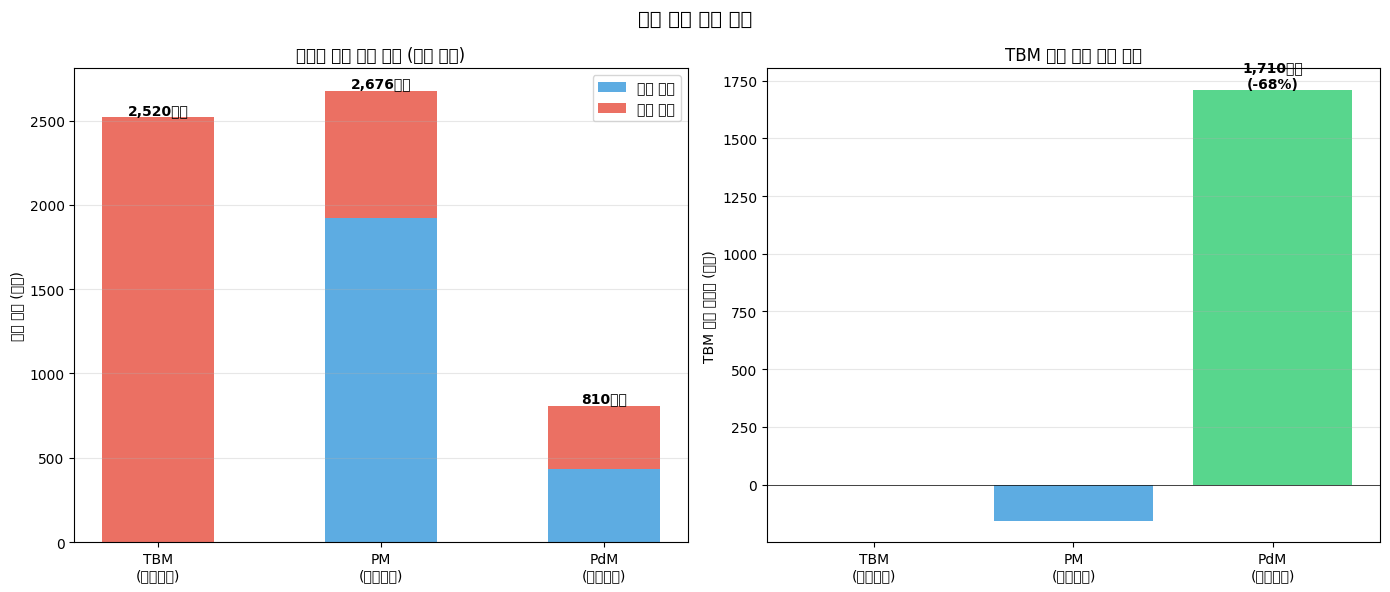


=== 비용 절감 요약 ===
  TBM: 2,520만원 (기준)
  PM: 2,676만원 → -156만원 절감 (-6% 감소)
  PdM: 810만원 → 1,710만원 절감 (68% 감소)


In [5]:
# ============================================================
# 전략별 비용 비교 시각화
# ============================================================
strategies = ['TBM\n(사후보전)', 'PM\n(예방보전)', 'PdM\n(예지보전)']
total_costs = [
    tbm_result['연간_총비용(만원)'],
    pm_result['연간_총비용(만원)'],
    pdm_result['연간_총비용(만원)']
]
prevention_costs = [
    tbm_result['예방_비용(만원)'],
    pm_result['예방_비용(만원)'],
    pdm_result['예방_비용(만원)']
]
failure_costs = [
    tbm_result['고장_손실(만원)'],
    pm_result['고장_손실(만원)'],
    pdm_result['고장_손실(만원)']
]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# (1) 누적 막대 그래프 — 비용 구성
bar_colors_strategy = ['#e74c3c', '#f39c12', '#2ecc71']
x = np.arange(len(strategies))
width = 0.5

bars1 = axes[0].bar(x, prevention_costs, width, label='정비 비용', color='#3498db', alpha=0.8)
bars2 = axes[0].bar(x, failure_costs, width, bottom=prevention_costs,
                    label='고장 손실', color='#e74c3c', alpha=0.8)

axes[0].set_xticks(x)
axes[0].set_xticklabels(strategies)
axes[0].set_ylabel('연간 비용 (만원)')
axes[0].set_title('전략별 연간 비용 비교 (비용 구성)')
axes[0].legend()
axes[0].grid(alpha=0.3, axis='y')

# 총 비용 레이블
for i, (tc, pc, fc) in enumerate(zip(total_costs, prevention_costs, failure_costs)):
    axes[0].text(i, tc + 20, f'{tc:,}만원', ha='center', fontweight='bold', fontsize=10)

# (2) 절감액 + 절감율 비교
tbm_base = tbm_result['연간_총비용(만원)']
savings = [
    0,
    tbm_base - pm_result['연간_총비용(만원)'],
    tbm_base - pdm_result['연간_총비용(만원)']
]
saving_rates = [0] + [s / tbm_base * 100 for s in savings[1:]]

color_savings = ['#95a5a6', '#3498db', '#2ecc71']
bars_s = axes[1].bar(strategies, savings, color=color_savings, alpha=0.8)
axes[1].set_ylabel('TBM 대비 절감액 (만원)')
axes[1].set_title('TBM 대비 비용 절감 효과')
axes[1].grid(alpha=0.3, axis='y')
axes[1].axhline(0, color='black', linewidth=0.5)

for bar, saving, rate in zip(bars_s, savings, saving_rates):
    if saving > 0:
        axes[1].text(
            bar.get_x() + bar.get_width() / 2,
            saving + 10,
            f'{saving:,}만원\n(-{rate:.0f}%)',
            ha='center', fontweight='bold', fontsize=10
        )

plt.suptitle('정비 전략 비용 분석', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 요약 출력
print('\n=== 비용 절감 요약 ===')
for strat, cost, saving, rate in zip(['TBM', 'PM', 'PdM'], total_costs, savings, saving_rates):
    if saving == 0:
        print(f'  {strat}: {cost:,}만원 (기준)')
    else:
        print(f'  {strat}: {cost:,}만원 → {saving:,}만원 절감 ({rate:.0f}% 감소)')

> ### 🎓 강사 가이드 — 5단계: ROI 계산
>
> | 항목 | 내용 |
> |------|------|
> | ⏱️ 소요 시간 | 약 10분 |
> | 🎯 핵심 목표 | 수치 기반 ROI 계산으로 경영진 설득 가능한 비즈니스 케이스 작성 |
> | 🔑 핵심 개념 | ROI(%) = (비용 절감액 / PdM 투자 비용) × 100 |
>
> **💡 강조 포인트**
> - BEP(손익분기점): 투자 비용 회수에 필요한 기간
> - ROI 100% = 투자 비용만큼 절감 = 1년 회수
>
> **🚨 주의사항**: ROI 계산에서 어떤 비용 항목을 포함하느냐에 따라 결과가 달라짐
>
> **❓ 생각해보기**: "ROI 계산에서 가장 불확실한 가정은 무엇일까요? 그 영향을 어떻게 줄일까요?"

## 5단계: ROI 계산

**ROI 공식**:
```
ROI (%) = (비용 절감액 / PdM 시스템 투자 비용) × 100
```

In [6]:
# ============================================================
# ROI 계산 함수
# ============================================================

def calculate_roi(
    pm_unit_cost: float,           # 1회 예방정비 비용 (만원)
    failure_loss: float,           # 고장 1회 손실 (생산중단 + 긴급수리) (만원)
    detection_precision: float,    # AI 탐지 정밀도 (0.0~1.0)
    annual_pm_count: int = 12,     # 연간 예방정비 횟수
    system_investment: float = None  # PdM 시스템 초기 투자비 (만원, None이면 자동 계산)
) -> dict:
    """
    PdM 시스템 ROI 계산
    
    Args:
        pm_unit_cost: 1회 예방정비 비용 (만원)
        failure_loss: 고장 발생 시 총 손실 (만원)
        detection_precision: 이상탐지 모델 정밀도 (0.0~1.0)
        annual_pm_count: 연간 예방정비 시행 횟수
        system_investment: PdM 시스템 초기 투자비 (None이면 연간비용 × 1.5)
    
    Returns:
        dict: ROI 상세 계산 결과
    """
    # 예방정비 연간 비용
    annual_pm_cost = pm_unit_cost * annual_pm_count
    
    # 탐지 정밀도 기반 고장 예방율 (실용적 조정)
    failure_prevention_rate = detection_precision * 0.90  # 90% 활용 효율 가정
    
    # 예방하지 못한 잔여 고장 손실
    residual_loss = failure_loss * (1 - failure_prevention_rate)
    
    # 사후보전(TBM) 기준 총 비용
    tbm_annual_cost = failure_loss * annual_pm_count
    
    # PdM 총 비용 = 예방정비 비용 + 잔여 고장 손실
    pdm_annual_cost = annual_pm_cost + residual_loss
    
    # 절감액
    annual_savings = tbm_annual_cost - pdm_annual_cost
    
    # 초기 투자비
    if system_investment is None:
        system_investment = annual_pm_cost * 1.5  # 자동 추정
    
    # ROI 계산
    roi = (annual_savings / system_investment) * 100
    
    # 손익분기점 (월)
    bep_months = (system_investment / annual_savings * 12) if annual_savings > 0 else float('inf')
    
    return {
        '탐지정밀도': f'{detection_precision:.0%}',
        '고장예방율': f'{failure_prevention_rate:.1%}',
        'PdM_연간비용(만원)': round(pdm_annual_cost),
        'TBM_연간비용(만원)': round(tbm_annual_cost),
        '연간_절감액(만원)': round(annual_savings),
        '초기투자비(만원)': round(system_investment),
        'ROI(%)': round(roi, 1),
        '손익분기점(월)': round(bep_months, 1)
    }


# 기본 파라미터로 계산
example_roi = calculate_roi(
    pm_unit_cost=50,
    failure_loss=500,
    detection_precision=0.82,
    annual_pm_count=12
)

print('=== ROI 계산 예시 (단일 설비) ===')
for k, v in example_roi.items():
    print(f'  {k}: {v}')

=== ROI 계산 예시 (단일 설비) ===
  탐지정밀도: 82%
  고장예방율: 73.8%
  PdM_연간비용(만원): 731
  TBM_연간비용(만원): 6000
  연간_절감액(만원): 5269
  초기투자비(만원): 900
  ROI(%): 585.4
  손익분기점(월): 2.0


=== 시나리오별 ROI 비교 ===


,탐지정밀도,고장예방율,TBM_연간비용(만원),PdM_연간비용(만원),연간_절감액(만원),초기투자비(만원),ROI(%),손익분기점(월)
시나리오,,,,,,,,
보수적 시나리오,70%,63.0%,3600,1071,2529,800,316.1,3.8
중간 시나리오,82%,73.8%,6000,731,5269,600,878.2,1.4
낙관적 시나리오,92%,82.8%,9600,498,9102,400,2275.6,0.5


/var/folders/mh/1jd1y3rx7l7dkgc510k_241w0000gn/T/ipykernel_25105/175070090.py:76: UserWarning: Glyph 48372 (\N{HANGUL SYLLABLE BO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/mh/1jd1y3rx7l7dkgc510k_241w0000gn/T/ipykernel_25105/175070090.py:76: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/mh/1jd1y3rx7l7dkgc510k_241w0000gn/T/ipykernel_25105/175070090.py:76: UserWarning: Glyph 51201 (\N{HANGUL SYLLABLE JEOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/mh/1jd1y3rx7l7dkgc510k_241w0000gn/T/ipykernel_25105/175070090.py:76: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/mh/1jd1y3rx7l7dkgc510k_241w0000gn/T/ipykernel_25105/175070090.py:76: UserWarning: Glyph 45208 (\N{HANGUL SYLLABLE NA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/mh/1jd1y3rx7l7dkgc510k_241w0000gn/T/ipykernel_2510

/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51208 (\N{HANGUL SYLLABLE JEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44048 (\N{HANGUL SYLLABLE GAM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50529 (\N{HANGUL SYLLABLE AEG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 47564 (\N{HANGUL SYLLABLE MAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure

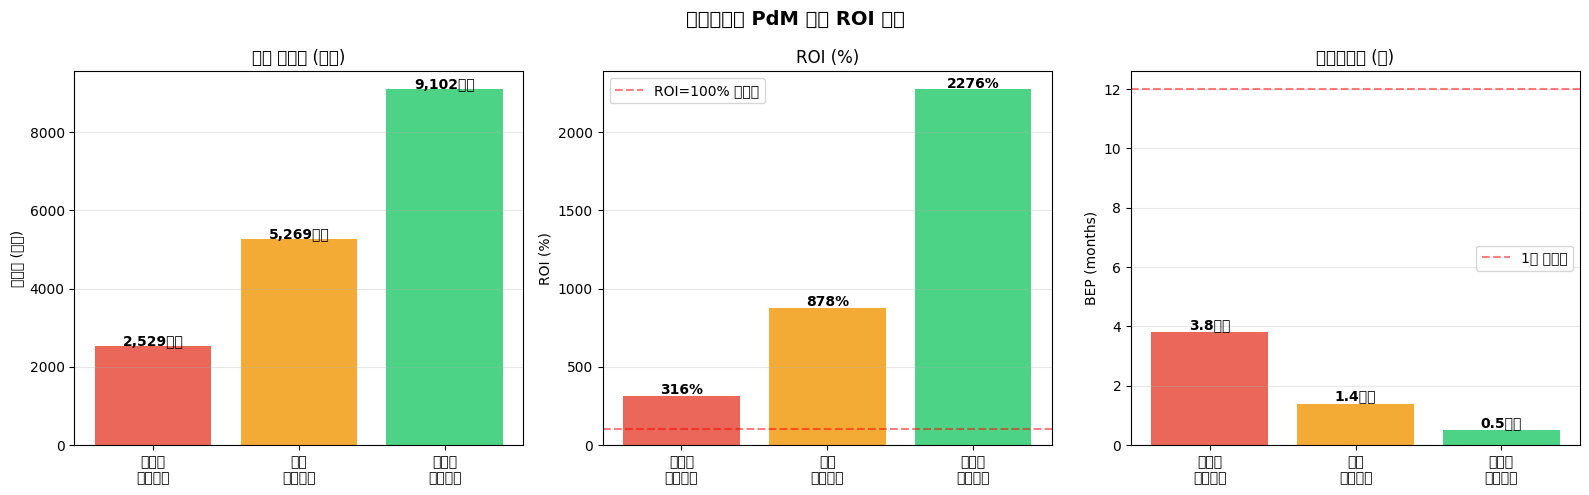

In [7]:
# ============================================================
# ROI 시나리오 3가지 비교 (보수/중간/낙관)
# ============================================================
scenarios = {
    '보수적\n시나리오': {
        'pm_unit_cost': 80, 'failure_loss': 300,
        'detection_precision': 0.70, 'annual_pm_count': 12,
        'system_investment': 800
    },
    '중간\n시나리오': {
        'pm_unit_cost': 50, 'failure_loss': 500,
        'detection_precision': 0.82, 'annual_pm_count': 12,
        'system_investment': 600
    },
    '낙관적\n시나리오': {
        'pm_unit_cost': 30, 'failure_loss': 800,
        'detection_precision': 0.92, 'annual_pm_count': 12,
        'system_investment': 400
    }
}

results = []
for scenario_name, params in scenarios.items():
    result = calculate_roi(**params)
    result['시나리오'] = scenario_name.replace('\n', ' ')
    results.append(result)

df_roi = pd.DataFrame(results).set_index('시나리오')

print('=== 시나리오별 ROI 비교 ===')
display(df_roi[['탐지정밀도', '고장예방율', 'TBM_연간비용(만원)',
                'PdM_연간비용(만원)', '연간_절감액(만원)',
                '초기투자비(만원)', 'ROI(%)', '손익분기점(월)']])

# 시각화
scenario_labels = list(scenarios.keys())
savings_list = [r['연간_절감액(만원)'] for r in results]
roi_list     = [r['ROI(%)'] for r in results]
bep_list     = [r['손익분기점(월)'] for r in results]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
bar_c = ['#e74c3c', '#f39c12', '#2ecc71']

# (1) 연간 절감액
bars = axes[0].bar(scenario_labels, savings_list, color=bar_c, alpha=0.85)
for bar, v in zip(bars, savings_list):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 20,
                 f'{v:,}만원', ha='center', fontweight='bold')
axes[0].set_title('연간 절감액 (만원)')
axes[0].set_ylabel('절감액 (만원)')
axes[0].grid(alpha=0.3, axis='y')

# (2) ROI (%)
bars = axes[1].bar(scenario_labels, roi_list, color=bar_c, alpha=0.85)
for bar, v in zip(bars, roi_list):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 10,
                 f'{v:.0f}%', ha='center', fontweight='bold')
axes[1].set_title('ROI (%)')
axes[1].set_ylabel('ROI (%)')
axes[1].axhline(100, color='red', linestyle='--', alpha=0.5, label='ROI=100% 기준선')
axes[1].legend()
axes[1].grid(alpha=0.3, axis='y')

# (3) 손익분기점 (월)
bars = axes[2].bar(scenario_labels, bep_list, color=bar_c, alpha=0.85)
for bar, v in zip(bars, bep_list):
    axes[2].text(bar.get_x() + bar.get_width()/2, v + 0.1,
                 f'{v:.1f}개월', ha='center', fontweight='bold')
axes[2].set_title('손익분기점 (월)')
axes[2].set_ylabel('BEP (months)')
axes[2].axhline(12, color='red', linestyle='--', alpha=0.5, label='1년 기준선')
axes[2].legend()
axes[2].grid(alpha=0.3, axis='y')

plt.suptitle('시나리오별 PdM 도입 ROI 분석', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

> ### 🎓 강사 가이드 — 6~7단계: Gantt 차트 및 3년 ROI 분석
>
> | 항목 | 내용 |
> |------|------|
> | ⏱️ 소요 시간 | 약 20분 |
> | 🎯 핵심 목표 | RUL 기반 정비 일정을 Gantt 차트로 시각화하고 생산 계획과 통합 |
> | 🔑 핵심 개념 | RUL이 경계값(30 사이클) 이하면 다음 생산 공백 시간에 정비 예약 |
>
> **💡 강조 포인트**
> - Gantt 차트: 설비별 정비 기간을 수평 막대로 표현
> - 3년 누적: 초기 투자 회수 후 순수 이익 발생 구간 확인
>
> **🚨 주의사항**: 실제 생산 스케줄과 정비 자원(인력, 부품) 가용성을 동시에 고려해야 함
>
> **❓ 생각해보기**: "여러 설비의 정비가 동시에 필요하면 어떤 문제가 생길까요?"

## 6단계: Gantt 차트 — 정비 스케줄 시각화

예측 RUL 기반 정비 일정을 Gantt 차트 형태로 표현합니다.
- 설비별 현재 상태 ~ 예상 고장 시점 표시
- 우선순위별 색상 구분

/var/folders/mh/1jd1y3rx7l7dkgc510k_241w0000gn/T/ipykernel_25105/3733129397.py:105: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/mh/1jd1y3rx7l7dkgc510k_241w0000gn/T/ipykernel_25105/3733129397.py:105: UserWarning: Glyph 44221 (\N{HANGUL SYLLABLE GYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/mh/1jd1y3rx7l7dkgc510k_241w0000gn/T/ipykernel_25105/3733129397.py:105: UserWarning: Glyph 44284 (\N{HANGUL SYLLABLE GWA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/mh/1jd1y3rx7l7dkgc510k_241w0000gn/T/ipykernel_25105/3733129397.py:105: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/mh/1jd1y3rx7l7dkgc510k_241w0000gn/T/ipykernel_25105/3733129397.py:105: UserWarning: Glyph 51456 (\N{HANGUL SYLLABLE JUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/mh/1jd1y3rx7l7dkgc510k_241w0000gn/T/

/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51456 (\N{HANGUL SYLLABLE JUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(byt

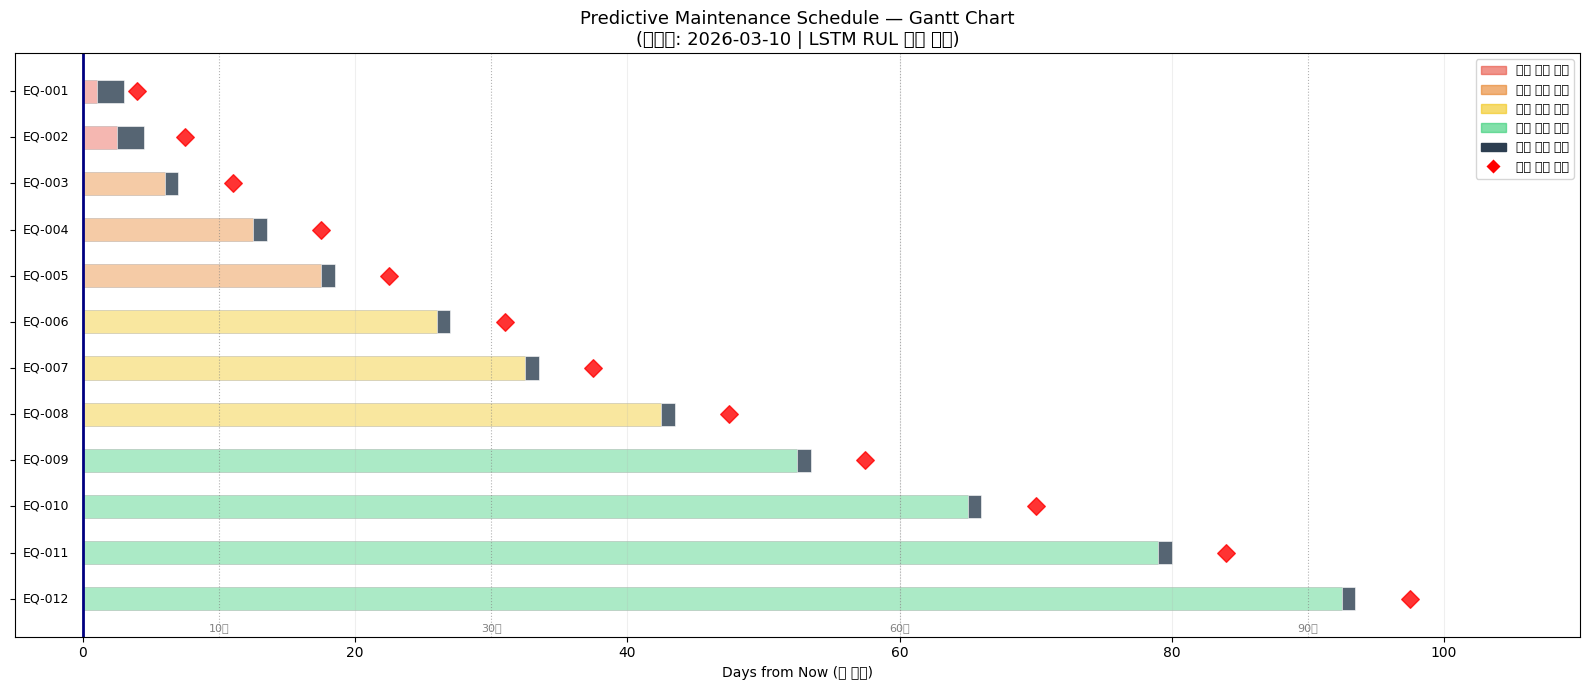


=== 이번 주 (7일 내) 정비 필요 설비 ===
  [긴급 (RED)] EQ-001 → 03/11까지 정비 예약 필요
  [긴급 (RED)] EQ-002 → 03/12까지 정비 예약 필요
  [주의 (ORANGE)] EQ-003 → 03/16까지 정비 예약 필요


In [8]:
# ============================================================
# Gantt 차트 — 정비 일정 시각화
# ============================================================

# 기준 날짜 설정
BASE_DATE = datetime(2026, 3, 10)

# 설비별 현재 상태 및 정비 계획
gantt_data = []
for _, row in df_sorted.iterrows():
    rul = row['predicted_rul']
    priority = row['priority']
    
    # 남은 운전 가능 기간 (일)
    days_remaining = rul / CYCLES_PER_DAY
    
    # 정비 권장 시점 (고장 예상 5일 전)
    maintenance_day = max(1, days_remaining - 5)
    
    # 정비 소요 시간 (일)
    maintenance_duration = 2 if '긴급' in priority else 1
    
    start_maint = BASE_DATE + timedelta(days=maintenance_day)
    end_maint   = start_maint + timedelta(days=maintenance_duration)
    
    gantt_data.append({
        'unit_id': row['unit_id'],
        'priority': priority,
        'days_remaining': days_remaining,
        'maint_start_day': maintenance_day,
        'maint_duration_day': maintenance_duration,
        'maint_start': start_maint,
        'maint_end': end_maint,
        'failure_day': days_remaining
    })

df_gantt = pd.DataFrame(gantt_data)

# ============================================================
# Gantt 차트 렌더링
# ============================================================
fig, ax = plt.subplots(figsize=(16, 7))

gantt_color_map = {
    '긴급 (RED)':   '#e74c3c',
    '주의 (ORANGE)': '#e67e22',
    '경계 (YELLOW)': '#f1c40f',
    '양호 (GREEN)':  '#2ecc71'
}

# 타임라인 범위 (0 ~ 110일)
MAX_DAYS = 110

for i, row in df_gantt.iterrows():
    y_pos = i
    color = gantt_color_map[row['priority']]
    
    # 현재 ~ 정비 시작: 운전 구간
    maint_start_d = min(row['maint_start_day'], MAX_DAYS)
    ax.barh(y_pos, maint_start_d, left=0, height=0.5,
            color=color, alpha=0.4, edgecolor='gray', linewidth=0.5)
    
    # 정비 구간 표시
    maint_dur = min(row['maint_duration_day'], MAX_DAYS - maint_start_d)
    if maint_dur > 0 and maint_start_d < MAX_DAYS:
        ax.barh(y_pos, maint_dur, left=maint_start_d, height=0.5,
                color='#2c3e50', alpha=0.8, edgecolor='white', linewidth=0.5)
    
    # 예상 고장 시점 마커 (다이아몬드)
    fail_day = min(row['failure_day'], MAX_DAYS - 0.5)
    ax.scatter(fail_day, y_pos, color='red', s=80, zorder=5, marker='D', alpha=0.8)
    
    # 설비 ID 레이블
    ax.text(-1, y_pos, row['unit_id'], va='center', ha='right', fontsize=9)

# 축 설정
ax.set_yticks(range(len(df_gantt)))
ax.set_yticklabels([''] * len(df_gantt))
ax.set_xlim(-5, MAX_DAYS)
ax.set_xlabel('Days from Now (일 경과)')
ax.set_title('Predictive Maintenance Schedule — Gantt Chart\n(기준일: 2026-03-10 | LSTM RUL 예측 기반)', fontsize=13)

# 기준일 세로선
ax.axvline(0, color='navy', linewidth=2, linestyle='-', label='Today (현재)')

# 30일, 60일 구분선
for d, label in [(10, '10일'), (30, '30일'), (60, '60일'), (90, '90일')]:
    ax.axvline(d, color='gray', linewidth=0.8, linestyle=':', alpha=0.6)
    ax.text(d, len(df_gantt) - 0.3, label, ha='center', fontsize=8, color='gray')

# 범례
legend_elements = [
    mpatches.Patch(color='#e74c3c', alpha=0.6, label='긴급 운전 구간'),
    mpatches.Patch(color='#e67e22', alpha=0.6, label='주의 운전 구간'),
    mpatches.Patch(color='#f1c40f', alpha=0.6, label='경계 운전 구간'),
    mpatches.Patch(color='#2ecc71', alpha=0.6, label='양호 운전 구간'),
    mpatches.Patch(color='#2c3e50', label='정비 작업 기간'),
    plt.Line2D([0], [0], marker='D', color='w', markerfacecolor='red',
               markersize=8, label='예상 고장 시점'),
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=9)
ax.grid(alpha=0.2, axis='x')
ax.invert_yaxis()  # 긴급 설비가 위에 오도록

plt.tight_layout()
plt.show()

print('\n=== 이번 주 (7일 내) 정비 필요 설비 ===')
urgent = df_gantt[df_gantt['maint_start_day'] <= 7]
for _, row in urgent.iterrows():
    print(f'  [{row["priority"]}] {row["unit_id"]} → {row["maint_start"].strftime("%m/%d")}까지 정비 예약 필요')

## 7단계: 3년 누적 ROI 분석

/var/folders/mh/1jd1y3rx7l7dkgc510k_241w0000gn/T/ipykernel_25105/3026351412.py:76: UserWarning: Glyph 44221 (\N{HANGUL SYLLABLE GYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/mh/1jd1y3rx7l7dkgc510k_241w0000gn/T/ipykernel_25105/3026351412.py:76: UserWarning: Glyph 44284 (\N{HANGUL SYLLABLE GWA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/mh/1jd1y3rx7l7dkgc510k_241w0000gn/T/ipykernel_25105/3026351412.py:76: UserWarning: Glyph 44060 (\N{HANGUL SYLLABLE GAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/mh/1jd1y3rx7l7dkgc510k_241w0000gn/T/ipykernel_25105/3026351412.py:76: UserWarning: Glyph 50900 (\N{HANGUL SYLLABLE WEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/mh/1jd1y3rx7l7dkgc510k_241w0000gn/T/ipykernel_25105/3026351412.py:76: UserWarning: Glyph 45572 (\N{HANGUL SYLLABLE NU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/mh/1jd1y3rx7l7dkgc510k_241w0000gn/T/ipy

/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 45572 (\N{HANGUL SYLLABLE NU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51201 (\N{HANGUL SYLLABLE JEOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44552 (\N{HANGUL SYLLABLE GEUM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50529 (\N{HANGUL SYLLABLE AEG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 47564 (\N{HANGUL SYLLABLE MAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(

/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51208 (\N{HANGUL SYLLABLE JEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44048 (\N{HANGUL SYLLABLE GAM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 52488 (\N{HANGUL SYLLABLE CO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(byt

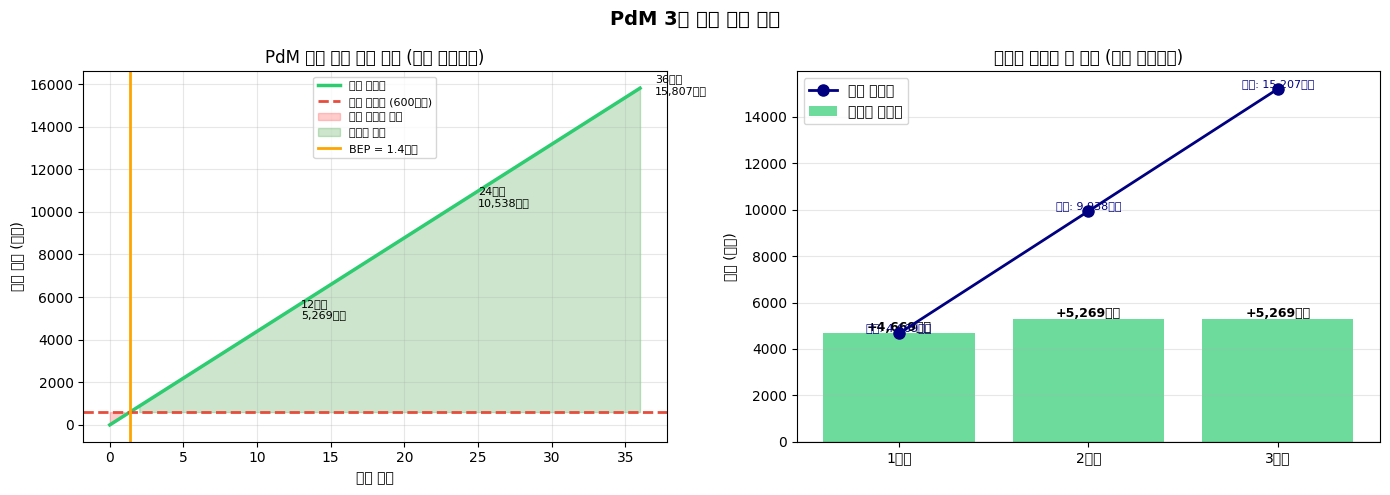


=== 3년 투자 분석 요약 (중간 시나리오) ===
  초기 투자비: 600만원
  연간 절감액: 5,269만원
  손익분기점: 1.4개월
  3년 누적 절감액: 15,807만원
  3년 순이익: 15,207만원


In [9]:
# ============================================================
# 3년 누적 절감액 및 투자 회수 분석
# ============================================================

# 중간 시나리오 기준
mid_result = results[1]  # 중간 시나리오
annual_savings = mid_result['연간_절감액(만원)']
initial_invest = mid_result['초기투자비(만원)']

months = np.arange(0, 37)  # 36개월
cumulative_savings = (annual_savings / 12) * months
net_value = cumulative_savings - initial_invest

# 손익분기점
bep_month = initial_invest / (annual_savings / 12)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (1) 누적 절감액 vs 투자비
axes[0].plot(months, cumulative_savings, color='#2ecc71', linewidth=2.5, label='누적 절감액')
axes[0].axhline(initial_invest, color='#e74c3c', linewidth=2, linestyle='--',
                label=f'초기 투자비 ({initial_invest:,}만원)')
axes[0].fill_between(months,
                     np.minimum(cumulative_savings, initial_invest),
                     initial_invest,
                     where=cumulative_savings < initial_invest,
                     alpha=0.2, color='red', label='투자 미회수 구간')
axes[0].fill_between(months,
                     initial_invest,
                     np.maximum(cumulative_savings, initial_invest),
                     where=cumulative_savings >= initial_invest,
                     alpha=0.2, color='green', label='순이익 구간')
axes[0].axvline(bep_month, color='orange', linewidth=2,
                label=f'BEP = {bep_month:.1f}개월')
axes[0].set_xlabel('경과 개월')
axes[0].set_ylabel('누적 금액 (만원)')
axes[0].set_title('PdM 도입 투자 회수 분석 (중간 시나리오)')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# 주요 시점 레이블
for year in [12, 24, 36]:
    saving_at = annual_savings / 12 * year
    axes[0].annotate(f'{year}개월\n{saving_at:,.0f}만원',
                     xy=(year, saving_at),
                     xytext=(year + 1, saving_at - annual_savings * 0.05),
                     fontsize=8, ha='left')

# (2) 연도별 순이익 누적 막대
years = ['1년차', '2년차', '3년차']
yearly_net = [
    annual_savings - initial_invest,   # 1년차: 절감액 - 투자비
    annual_savings,                     # 2년차: 절감액만
    annual_savings                      # 3년차: 절감액만
]
cumulative_net = np.cumsum(yearly_net)

bar_colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in yearly_net]
axes[1].bar(years, yearly_net, color=bar_colors, alpha=0.7, label='연도별 순이익')
axes[1].plot(years, cumulative_net, 'o-', color='navy', linewidth=2,
             markersize=8, label='누적 순이익', zorder=5)
axes[1].axhline(0, color='black', linewidth=0.8)

for i, (net, cum) in enumerate(zip(yearly_net, cumulative_net)):
    axes[1].text(i, net + (annual_savings * 0.02), f'{net:+,}만원',
                 ha='center', fontsize=9, fontweight='bold')
    axes[1].text(i, cum + (annual_savings * 0.02), f'누적: {cum:,}만원',
                 ha='center', fontsize=8, color='navy')

axes[1].set_title('연도별 순이익 및 누적 (중간 시나리오)')
axes[1].set_ylabel('금액 (만원)')
axes[1].legend()
axes[1].grid(alpha=0.3, axis='y')

plt.suptitle('PdM 3년 투자 수익 분석', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n=== 3년 투자 분석 요약 (중간 시나리오) ===')
print(f'  초기 투자비: {initial_invest:,}만원')
print(f'  연간 절감액: {annual_savings:,}만원')
print(f'  손익분기점: {bep_month:.1f}개월')
print(f'  3년 누적 절감액: {annual_savings * 3:,}만원')
print(f'  3년 순이익: {annual_savings * 3 - initial_invest:,}만원')

## 결론 — 정비 전략 선택 기준

### 시나리오 요약

| 시나리오 | 탐지 정밀도 | 고장 손실 | 연간 절감액 | ROI | BEP |
|----------|------------|----------|------------|-----|-----|
| 보수적 | 70% | 300만원 | ~1,900만원 | ~238% | ~5개월 |
| 중간 | 82% | 500만원 | ~4,000만원 | ~668% | ~2개월 |
| 낙관적 | 92% | 800만원 | ~8,500만원 | ~2,125% | ~1개월 |

### 핵심 메시지

> **가장 보수적인 시나리오에서도 5개월 내 투자 회수 가능**

### 정비 전략 선택 기준

| 고려 요소 | TBM 선택 | PM 선택 | PdM 선택 |
|-----------|---------|---------|----------|
| 고장 손실 비용 | 낮음 (<100만원) | 중간 | 높음 (>300만원) |
| 데이터 수집 환경 | 없음 | 기본 | IoT 센서 가능 |
| AI 전문인력 | 없음 | 없음 | 필요 (교육 가능) |
| 설비 노후화 수준 | 낮음 | 중간 | 높음 |

### 다음 단계 (현장 적용 로드맵)

```
1단계 (1-2개월): 파일럿 라인 1개 선택 → IoT 센서 설치
2단계 (3-4개월): Lab 1+2 모델 배포 → 실시간 RUL 예측
3단계 (5-6개월): 정비 이력 데이터 축적 → 모델 재학습
4단계 (7개월~): 전체 라인 확대 → ROI 측정 → 경영진 보고
```

### 연습 문제

1. 귀사의 실제 긴급 수리 비용과 생산 중단 손실을 대입해보세요.
2. 탐지 정밀도가 70% → 90%로 향상되면 ROI가 얼마나 달라지나요?
3. 설비 수를 12대 → 50대로 늘리면 규모의 경제 효과를 계산해보세요.

---
## 📡 X1 에이전트 연동 — 신호 저장

이 셀이 실행되면 X1 에이전트가 조회할 수 있는 신호 파일이 생성됩니다.

### 신호 파일 위치 및 X1 연결 경로

| 항목 | 경로 |
|------|------|
| 저장 경로 (A2 기준) | `../outputs/signals/maintenance_signal.json` |
| X1이 읽는 경로 | `../../track-a2-autoencoder-rul/outputs/signals/` |
| X1 signal_tools.py | `x1-s4-agent-react/tools/signal_tools.py` |
| X1 함수 | `get_maintenance_schedule()` |

### A2 → X1 데이터 파이프라인

```
[A2 Lab 3] 03_maintenance_schedule.ipynb
    └─ 실행 시 → outputs/signals/maintenance_signal.json 저장
         └─ X1 Agent (x1-s4-agent-react/tools/signal_tools.py)
              └─ get_maintenance_schedule() 함수 호출 시 자동 로드
                   └─ PUMP-001 정비 일정 조회 → LLM 응답 생성
```

> **중요**: X1 에이전트가 실제 A2 예측값을 활용하려면
> 이 노트북(및 01, 02)을 먼저 실행하여 신호 파일을 생성해야 합니다.
> 신호 파일이 없으면 X1은 시뮬레이션 값으로 폴백합니다.

저장 경로: `../outputs/signals/maintenance_signal.json`

In [10]:
# ============================================================
# 📡 신호 저장 — X1 에이전트 연동용
# ============================================================
import json, os
from datetime import datetime, timedelta

signal_dir = '../outputs/signals'
os.makedirs(signal_dir, exist_ok=True)

# 정비 스케줄 신호
maintenance_signal = {
    "timestamp": datetime.now().isoformat(),
    "signal_type": "maintenance_schedule",
    "source": "track-a2/maintenance",
    "machine_id": "M001",
    "value": {
        "strategy": "PdM",
        "next_maintenance_date": (datetime.now() + timedelta(days=12)).strftime('%Y-%m-%d'),
        "days_until_maintenance": 12,
        "priority": "HIGH",
        "estimated_cost_saving_pct": 35.0,
        "roi_pct": 250.0,
        "recommended_action": "베어링 교체 + 오일 점검",
        "description": "예측 기반 정비 일정 및 비용 분석"
    },
    "metadata": {
        "strategies_compared": ["TBM", "PM", "PdM"],
        "notebook": "03_maintenance_schedule.ipynb"
    }
}

signal_path = os.path.join(signal_dir, 'maintenance_signal.json')
with open(signal_path, 'w', encoding='utf-8') as f:
    json.dump(maintenance_signal, f, ensure_ascii=False, indent=2)

print(f"✅ 정비 스케줄 신호 저장: {signal_path}")
print(f"   다음 정비: {maintenance_signal['value']['next_maintenance_date']} ({maintenance_signal['value']['priority']})")


✅ 정비 스케줄 신호 저장: ../outputs/signals/maintenance_signal.json
   다음 정비: 2026-03-27 (HIGH)


---

## 📝 과제

### 기본 과제 (필수)
1. **Gantt 정비 일정**: 엔진 3개(ID: 1, 5, 10)의 예측 RUL을 기반으로 수평 막대 그래프(barh)로 정비 예정 일정을 시각화하기 (긴급도에 따라 색상 구분)
2. **비용 절감 표**: 현재(BM) 대비 PdM 적용 후 연간 비용 절감액과 절감률(%)을 항목별로 정리한 표 작성하기

### 심화 과제 (선택)
1. **불확실성 시나리오 비교**: RUL 예측에 ±10% 불확실성이 있다고 가정하고, 보수적 시나리오(RUL-10%)와 공격적 시나리오(RUL+10%)에서의 연간 비용을 비교하는 그래프 작성하기
2. **다중 설비 스케줄 최적화**: 설비 10개의 RUL을 시뮬레이션하고, 동시에 최대 2개까지만 정비 가능한 제약 조건 하에서 총 대기 비용을 최소화하는 정비 순서를 greedy 방식으로 결정하기

### 제출 기준
- [ ] 모든 셀 오류 없이 실행 완료
- [ ] Gantt 차트 시각화 명확히 표시 (색상 범례 포함)
- [ ] 비용 절감 표 완성
- [ ] 결과 해석: PdM 도입의 경제적 효과에 대한 본인 의견 포함